/home/mmw/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mmw/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

交互监听已启用。点击图像生成 mask。
停止监听请运行: fig.canvas.mpl_disconnect(cid)


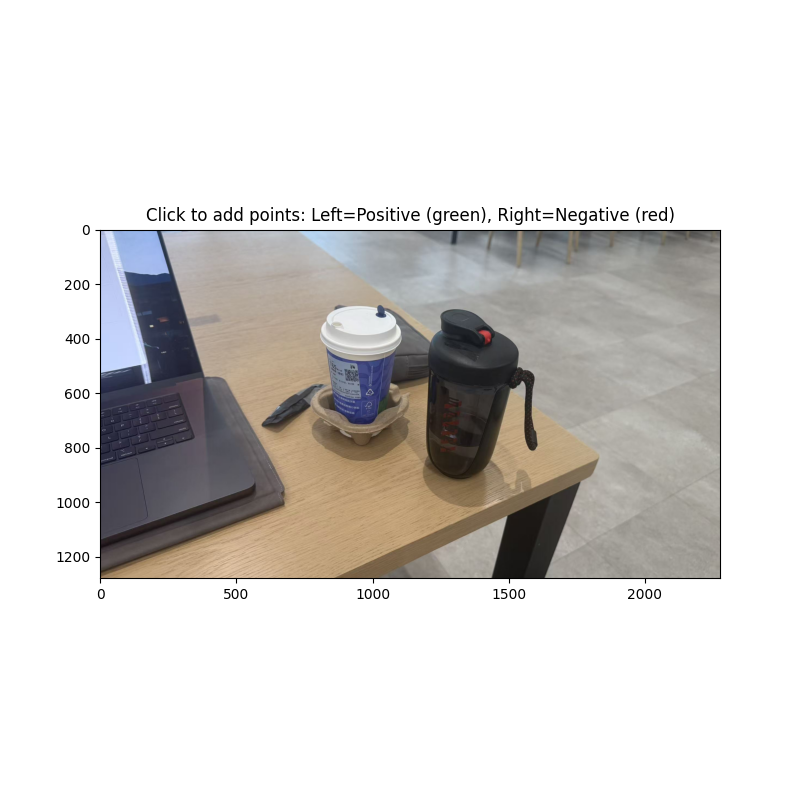

In [3]:
# ================== 1. 必须启用 widget 后端 ==================
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import cv2
import json
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

# ================== 2. 配置 ==================
image_path = "/data/mmw/test/segment-anything/notebooks/images/airpods.jpg"

# 读取图像
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"图像未找到: {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # BGR -> RGB

# 点击记录
clicked_points = []
point_labels = []  # 左键=1，右键=0

# ================== 3. 加载 SAM 模型 ==================
sam_checkpoint = "/data/mmw/test/segment-anything/checkpoints/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)
predictor.set_image(image)

# ================== 4. 绘制 Figure ==================
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(image)
ax.set_title("Click to add points: Left=Positive (green), Right=Negative (red)")

# ================== 5. 显示点和 mask 的辅助函数 ==================
def show_mask(mask, ax, alpha=0.5):
    ax.imshow(mask, alpha=alpha)

def show_points(coords, labels, ax):
    coords = np.array(coords)
    labels = np.array(labels)
    for pt, lbl in zip(coords, labels):
        ax.scatter(pt[0], pt[1], color='green' if lbl==1 else 'red',
                   marker='*', s=200, edgecolor='white', linewidth=1.25)

# ================== 6. 鼠标点击事件回调 ==================
def onclick(event):
    global clicked_points, point_labels

    if event.xdata is None or event.ydata is None:
        return

    x, y = int(event.xdata), int(event.ydata)

    # 左键=1, 右键=0
    if event.button == 1:
        clicked_points.append([x, y])
        point_labels.append(1)
        label_value = 1
        print(f"Left click: ({x},{y}) → label 1")
    elif event.button == 3:
        clicked_points.append([x, y])
        point_labels.append(0)
        label_value = 0
        print(f"Right click: ({x},{y}) → label 0")
    else:
        return

    # ================== 6.1 SAM 推理 ==================
    input_points = np.array(clicked_points)
    input_labels = np.array(point_labels)
    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True  # 输出多个 mask
    )

    if len(masks) == 0:
        print("No masks returned")
        return

    # ================== 6.2 选择最优 mask ==================
    best_idx = int(np.argmax(scores))
    best_mask = masks[best_idx]

    # ================== 6.3 保存最优 mask ==================
    mask_image = (best_mask * 255).astype(np.uint8)
    mask_filename = f"/data/mmw/test/data_online/mask_{x}_{y}.png"
    cv2.imwrite(mask_filename, mask_image)
    print(f"最优 mask 已保存为 {mask_filename}")

    # ================== 6.4 显示叠加效果 + 点击点 ==================
    ax.clear()
    ax.imshow(image)
    show_mask(best_mask, ax, alpha=0.5)
    show_points(clicked_points, point_labels, ax)
    ax.set_title(f'Clicked: ({x},{y}) — best_score={scores[best_idx]:.3f}')
    fig.canvas.draw()

# 绑定事件
cid = fig.canvas.mpl_connect('button_press_event', onclick)

# ================== 7. 保存点击点函数 ==================
def save_points(filename="/data/mmw/test/data_online/clicked_points.json"):
    data = {"points": clicked_points, "labels": point_labels}
    with open(filename, "w") as f:
        json.dump(data, f, indent=2)
    print(f"保存完成: {filename}")

print("交互监听已启用。点击图像生成 mask。")
print("停止监听请运行: fig.canvas.mpl_disconnect(cid)")


In [4]:
fig.canvas.mpl_disconnect(cid)